# Clasificación de Matrimonios en México 2024: Predicción del Género del Matrimonio

**Curso**: SC3314 – Inteligencia Artificial

**Institución**: Universidad de Monterrey

**Profesor**: Dr. Antonio Martínez Torteya

**Proyecto**: Proyecto Final - Unidad 2

**Fecha**: 2026

## 1. Planteamiento del Problema y Contexto de los Datos

### 1.1 Descripción del Problema

Este proyecto desarrolla un modelo de clasificación para predecir el **género del matrimonio** en México durante 2024, diferenciando entre matrimonios heterosexuales (Género 1) y matrimonios del mismo sexo (Género 2).

### 1.2 Relevancia del Problema

La diversidad en las formas de matrimonio es un aspecto importante de la realidad social contemporánea de México. En los últimos años, la legislación mexicana ha permitido matrimonios del mismo sexo en todas las entidades federativas. Comprender qué características demográficas, económicas y geográficas se asocian con los matrimonios del mismo sexo proporciona información valiosa sobre los patrones sociales y facilita la identificación de factores que influyen en esta decisión vital.

### 1.3 Origen de los Datos

Los datos provienen del **Registro Civil de México, año 2024**, específicamente del conjunto de datos oficial sobre matrimonios (Conjunto de Datos EMAT2024). Esta es una fuente institucional confiable que recopila información de todas las entidades federativas del país.

**Características del dataset:**
- Registros: Matrimonios celebrados en México durante 2024
- Fuente: Institución pública oficial
- Variables: 35 campos que incluyen información demográfica, económica y geográfica de ambos contrayentes
- Formato: CSV con 35 columnas

### 1.4 Variable Objetivo

**Variable**: `genero`

**Definición**: Género del matrimonio (clasificación binaria)
- **Clase 1**: Matrimonio heterosexual (combinación de hombres y mujeres)
- **Clase 2**: Matrimonio del mismo sexo

### 1.5 Justificación del Enfoque de Clasificación

Un enfoque de clasificación es apropiado porque:
1. La variable objetivo es categórica y toma exactamente dos valores
2. Permite establecer relaciones entre características del matrimonio y su género
3. El objetivo es predecir una etiqueta (clase) en lugar de un valor continuo
4. Posibilita la evaluación del modelo mediante métricas estándar de clasificación

## 2. Importación de Librerías y Configuración Inicial

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 3. Exploración y Comprensión del Conjunto de Datos

### 3.1 Carga de Datos

In [36]:
df = pd.read_csv('conjunto_de_datos_emat2024_csv/conjunto_de_datos/conjunto_de_datos_emat2024.csv')
print(f'Dimensiones del dataset: {df.shape}')
print(f'\nPrimeras filas:')
print(df.head())

Dimensiones del dataset: (486645, 35)

Primeras filas:
   ent_regis  mun_regis  loc_regis  tam_loc_re  dia_regis  mes_regis  anio_regis  regimen_ma  genero  sexo_con1  edad_con1  naci_con1  ocup_con1  entrh_con1  munrh_con1  locrh_con1  tlorh_con1  escol_con1  conactcon1  sitlabcon1  postracon1  sexo_con2  edad_con2  naci_con2  ocup_con2  entrh_con2  munrh_con2  locrh_con2  tlorh_con2  escol_con2  conactcon2  sitlabcon2  postracon2  tipo_con  dis_re_oax
0          1          1          1          15          4          1        2024           1       1          1         39          1         98           1           1           1          15           7           1           1           2          2         42          2         98           1           1           1          15           7           1           1           2         1         999
1          1          1          1          15         29          6        2024           9       1          1         27          1      

In [37]:
print(f'Información del dataset:')
print(df.info())

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 486645 entries, 0 to 486644
Data columns (total 35 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   ent_regis   486645 non-null  int64
 1   mun_regis   486645 non-null  int64
 2   loc_regis   486645 non-null  int64
 3   tam_loc_re  486645 non-null  int64
 4   dia_regis   486645 non-null  int64
 5   mes_regis   486645 non-null  int64
 6   anio_regis  486645 non-null  int64
 7   regimen_ma  486645 non-null  int64
 8   genero      486645 non-null  int64
 9   sexo_con1   486645 non-null  int64
 10  edad_con1   486645 non-null  int64
 11  naci_con1   486645 non-null  int64
 12  ocup_con1   486645 non-null  int64
 13  entrh_con1  486645 non-null  int64
 14  munrh_con1  486645 non-null  int64
 15  locrh_con1  486645 non-null  int64
 16  tlorh_con1  486645 non-null  int64
 17  escol_con1  486645 non-null  int64
 18  conactcon1  486645 non-null  int64
 19  sitlabcon1  486645 non-null  i

### 3.2 Análisis de la Variable Objetivo

Distribución de la variable objetivo (genero):
genero
1    480333
2      6312
Name: count, dtype: int64

Proporción:
genero
1    98.702956
2     1.297044
Name: proportion, dtype: float64


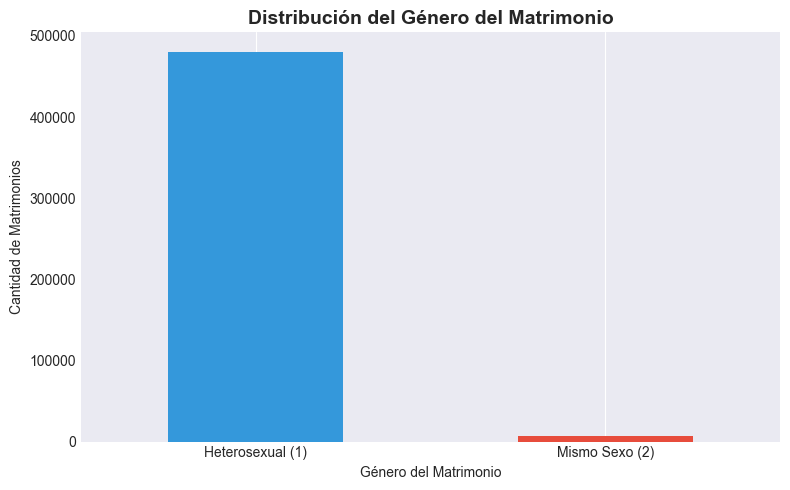

In [38]:
print('Distribución de la variable objetivo (genero):')
print(df['genero'].value_counts())
print(f'\nProporción:')
print(df['genero'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
df['genero'].value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('Distribución del Género del Matrimonio', fontsize=14, fontweight='bold')
plt.xlabel('Género del Matrimonio')
plt.ylabel('Cantidad de Matrimonios')
plt.xticks([0, 1], ['Heterosexual (1)', 'Mismo Sexo (2)'], rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### 3.3 Descripción de Variables Disponibles

In [39]:
print('Descripción estadística de variables numéricas:')
print(df.describe())

Descripción estadística de variables numéricas:
           ent_regis      mun_regis      loc_regis     tam_loc_re      dia_regis      mes_regis  anio_regis     regimen_ma         genero      sexo_con1      edad_con1      naci_con1      ocup_con1     entrh_con1     munrh_con1     locrh_con1     tlorh_con1     escol_con1     conactcon1     sitlabcon1     postracon1      sexo_con2      edad_con2      naci_con2      ocup_con2     entrh_con2     munrh_con2     locrh_con2     tlorh_con2     escol_con2     conactcon2     sitlabcon2     postracon2       tipo_con     dis_re_oax
count  486645.000000  486645.000000  486645.000000  486645.000000  486645.000000  486645.000000    486645.0  486645.000000  486645.000000  486645.000000  486645.000000  486645.000000  486645.000000  486645.000000  486645.000000  486645.000000  486645.000000  486645.000000  486645.000000  486645.000000  486645.000000  486645.000000  486645.000000  486645.000000  486645.000000  486645.000000  486645.000000  486645.000000  

In [40]:
print('Valores faltantes por columna:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No hay valores faltantes')

Valores faltantes por columna:
No hay valores faltantes


### 3.4 Diccionario de Datos

| Código | Campo | Descripción |
|--------|-------|-------------|
| ent_regis | Entidad de registro | Entidad federativa donde se registró el matrimonio |
| mun_regis | Municipio de registro | Municipio o alcaldía del registro |
| tam_loc_re | Tamaño de localidad | Tamaño de la localidad (1-17: pequeño a grande, 99: no especificado) |
| genero | Género del matrimonio | 1: Heterosexual, 2: Mismo sexo |
| sexo_con1, sexo_con2 | Sexo de contrayentes | 1: Hombre, 2: Mujer |
| edad_con1, edad_con2 | Edad de contrayentes | Edad en años (12-99) |
| naci_con1, naci_con2 | Nacionalidad | 1: Mexicana, 2: Extranjera |
| ocup_con1, ocup_con2 | Ocupación | 1-11: distintas ocupaciones, 97-99: valores especiales |
| escol_con1, escol_con2 | Escolaridad | 1-9: niveles de escolaridad |
| conactcon1, conactcon2 | Condición de actividad económica | 1: Trabaja, 2: No trabaja, 9: No especificado |
| tipo_con | Tipo de contrayentes | 1, 2, 3: distintas combinaciones |
| regimen_ma | Régimen matrimonial | 1: Sociedad conyugal, 2: Separación de bienes, 3: Otro, 9: No especificado |

### 3.5 Análisis de Balance de Clases

In [41]:
clase_1 = (df['genero'] == 1).sum()
clase_2 = (df['genero'] == 2).sum()
proporcion = clase_2 / clase_1

print(f'Matrimonios heterosexuales: {clase_1} ({clase_1/len(df)*100:.2f}%)')
print(f'Matrimonios del mismo sexo: {clase_2} ({clase_2/len(df)*100:.2f}%)')
print(f'\nProporción clase minoritaria/mayoritaria: 1:{1/proporcion:.1f}')
print(f'\nEl dataset está desbalanceado, con más matrimonios heterosexuales que del mismo sexo.')

Matrimonios heterosexuales: 480333 (98.70%)
Matrimonios del mismo sexo: 6312 (1.30%)

Proporción clase minoritaria/mayoritaria: 1:76.1

El dataset está desbalanceado, con más matrimonios heterosexuales que del mismo sexo.


## 4. Preparación y Tratamiento de los Datos

### 4.1 Selección de Características Relevantes

### 4.1 Justificación de la Selección de las 17 Características

La selección de estas 17 variables se realizó para maximizar la capacidad predictiva del modelo y, al mismo tiempo, mantener una estructura interpretable y consistente con el problema.

**Razones principales:**

1. **Relevancia sociodemográfica directa**  
    Se incluyen variables clave como edad, sexo, nacionalidad, ocupación y escolaridad de ambos contrayentes, ya que describen perfiles poblacionales asociados al tipo de matrimonio.

2. **Información de ambos contrayentes**  
    Se usan variables espejo para `con1` y `con2` (por ejemplo, `edad_con1` y `edad_con2`) para capturar la dinámica de la pareja, no solo características individuales.

3. **Contexto geográfico y territorial**  
    Variables como `tam_loc_re`, `tlorh_con1` y `tlorh_con2` incorporan diferencias entre entornos urbanos/rurales y lugar de residencia, factores potencialmente relacionados con patrones matrimoniales.

4. **Dimensión socioeconómica**  
    `ocup_con1`, `ocup_con2`, `conactcon1` y `conactcon2` aportan señales sobre condición laboral y actividad económica.

5. **Factores institucionales del vínculo**  
    `tipo_con` y `regimen_ma` representan características legales/administrativas del matrimonio que pueden diferenciar comportamientos entre clases.

6. **Evitar variables poco útiles o redundantes**  
    Se excluyen campos identificadores o de registro (por ejemplo, folios, fechas exactas o códigos administrativos muy específicos) que aportan poca generalización o pueden introducir ruido.

7. **Balance entre desempeño e interpretabilidad**  
    Un conjunto de 17 características permite entrenar modelos robustos sin sobrecargar el espacio de variables, facilitando además la interpretación de resultados e importancia de atributos.

In [42]:
features_seleccionadas = [
    'tam_loc_re', 'sexo_con1', 'edad_con1', 'naci_con1', 'ocup_con1', 
    'escol_con1', 'conactcon1', 'sexo_con2', 'edad_con2', 'naci_con2', 
    'ocup_con2', 'escol_con2', 'conactcon2', 'tipo_con', 'regimen_ma',
    'tlorh_con1', 'tlorh_con2'
]

df_modelo = df[features_seleccionadas + ['genero']].copy()

print(f'Features seleccionadas: {len(features_seleccionadas)}')
print(f'Dimensiones después de selección: {df_modelo.shape}')

Features seleccionadas: 17
Dimensiones después de selección: (486645, 18)


### 4.2 Manejo de Valores Especiales

In [43]:
valores_especiales = {9: np.nan, 97: np.nan, 98: np.nan, 99: np.nan}

columnas_limpiar = ['tam_loc_re', 'ocup_con1', 'ocup_con2', 'regimen_ma', 'conactcon1', 'conactcon2']

for col in columnas_limpiar:
    if col in df_modelo.columns:
        df_modelo[col] = df_modelo[col].replace(valores_especiales)

print('Valores faltantes después de limpieza:')
print(df_modelo.isnull().sum())

Valores faltantes después de limpieza:
tam_loc_re     21001
sexo_con1          0
edad_con1          0
naci_con1          0
ocup_con1     408056
escol_con1         0
conactcon1     12953
sexo_con2          0
edad_con2          0
naci_con2          0
ocup_con2     286469
escol_con2         0
conactcon2     25754
tipo_con           0
regimen_ma      4140
tlorh_con1         0
tlorh_con2         0
genero             0
dtype: int64


### 4.3 Imputación de Valores Faltantes

In [44]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df_modelo[features_seleccionadas] = imputer.fit_transform(df_modelo[features_seleccionadas])

print('Después de imputación:')
print(df_modelo.isnull().sum().sum() == 0)
print('\nDataset sin valores faltantes')

Después de imputación:
True

Dataset sin valores faltantes


### 4.4 Separación de Características y Variable Objetivo

In [45]:
X = df_modelo[features_seleccionadas]
y = df_modelo['genero']

print(f'Dimensiones de X: {X.shape}')
print(f'Dimensiones de y: {y.shape}')
print(f'\nValores únicos en y: {y.unique()}')

Dimensiones de X: (486645, 17)
Dimensiones de y: (486645,)

Valores únicos en y: [1 2]


### 4.5 División en Conjuntos de Entrenamiento y Prueba

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Tamaño conjunto entrenamiento: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Tamaño conjunto prueba: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nDistribución en entrenamiento:')
print(y_train.value_counts())
print(f'\nDistribución en prueba:')
print(y_test.value_counts())

Tamaño conjunto entrenamiento: 389316 (80.0%)
Tamaño conjunto prueba: 97329 (20.0%)

Distribución en entrenamiento:
genero
1    384266
2      5050
Name: count, dtype: int64

Distribución en prueba:
genero
1    96067
2     1262
Name: count, dtype: int64


### 4.6 Escalamiento de Características

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=features_seleccionadas)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features_seleccionadas)

print('Datos escalados correctamente')
print(f'Media de X_train_scaled: {X_train_scaled.mean().mean():.6f}')
print(f'Desv. Est. de X_train_scaled: {X_train_scaled.std().mean():.6f}')

Datos escalados correctamente
Media de X_train_scaled: -0.000000
Desv. Est. de X_train_scaled: 1.000001


## 5. Construcción y Comparación de Modelos

### 5.1 Definición de Métricas de Evaluación

In [48]:
def evaluar_modelo(modelo, X_train, X_test, y_train, y_test, nombre):
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)
    
    metricas = {
        'Modelo': nombre,
        'Accuracy_Train': accuracy_score(y_train, y_pred_train),
        'Accuracy_Test': accuracy_score(y_test, y_pred_test),
        'Precision': precision_score(y_test, y_pred_test),
        'Recall': recall_score(y_test, y_pred_test),
        'F1-Score': f1_score(y_test, y_pred_test)
    }
    
    if hasattr(modelo, 'predict_proba'):
        y_proba = modelo.predict_proba(X_test)[:, 1]
        metricas['ROC-AUC'] = roc_auc_score(y_test, y_proba)
    
    return metricas, y_pred_test

resultados_modelos = []

### 5.2 Modelo 1: Regresión Logística

En esta etapa se entrenará un modelo de **Regresión Logística** para predecir la variable objetivo `genero` (1: heterosexual, 2: mismo sexo) a partir de las 17 características seleccionadas.

La idea es que el modelo aprenda la relación entre las variables de entrada (edad, escolaridad, ocupación, condición de actividad, tipo de unión, régimen, etc.) y la probabilidad de pertenecer a cada clase.

**¿Qué se hará específicamente?**
- Entrenar el modelo con `X_train_scaled` y `y_train`.
- Generar predicciones sobre entrenamiento y prueba.
- Evaluar desempeño con métricas de clasificación: **Accuracy, Precision, Recall, F1 y ROC-AUC**.
- Comparar su rendimiento contra los demás modelos del proyecto.

**Utilidad en este caso**
- Es un algoritmo adecuado para **clasificación binaria**.
- Entrega **probabilidades**, no solo clases, lo que permite interpretar nivel de confianza.
- Sus coeficientes permiten analizar qué variables están asociadas con mayor o menor probabilidad de cada tipo de matrimonio.
- Funciona bien como referencia inicial cuando se tienen muchas observaciones y variables numéricas/codificadas.

**Razón de su uso**
La Regresión Logística se utiliza aquí como un modelo base sólido por su equilibrio entre:
1. **Buen desempeño predictivo** en problemas binarios.
2. **Interpretabilidad** (importante en un análisis social).
3. **Eficiencia computacional** para un dataset grande como este.
4. **Facilidad de comparación** con modelos más complejos (ensambles, SVM, red neuronal).

In [49]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

metricas_lr, pred_lr = evaluar_modelo(
    lr_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Regresión Logística'
)
resultados_modelos.append(metricas_lr)

print('Regresión Logística')
for key, value in metricas_lr.items():
    print(f'{key}: {value:.4f}' if key != 'Modelo' else f'{key}: {value}')

Regresión Logística
Modelo: Regresión Logística
Accuracy_Train: 1.0000
Accuracy_Test: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0000


### 5.3 Modelo 2: Linear Discriminant Analysis (LDA)

En esta etapa se entrenará un modelo de **Linear Discriminant Analysis (LDA)** para predecir la variable objetivo `genero` (1: heterosexual, 2: mismo sexo) usando las 17 variables seleccionadas.

**¿Qué se hará específicamente?**
- Ajustar el modelo con `X_train_scaled` y `y_train`.
- Generar predicciones en entrenamiento y prueba.
- Evaluar su desempeño con **Accuracy, Precision, Recall, F1-Score y ROC-AUC**.
- Comparar sus resultados con los demás modelos del proyecto.

**Utilidad en este caso**
- LDA es un método clásico para **clasificación binaria** y multiclase.
- Busca combinaciones lineales de variables que **separen mejor las clases**.
- Es eficiente para datasets grandes y puede funcionar bien con variables numéricas escaladas.
- Sirve como modelo interpretable y competitivo frente a alternativas más complejas.

**Razón de su uso**
Se incluye LDA porque:
1. Es un modelo lineal robusto y rápido de entrenar.
2. Permite evaluar si una frontera lineal discrimina bien entre ambos tipos de matrimonio.
3. Complementa a Regresión Logística al ofrecer otro enfoque estadístico de separación de clases.
4. Proporciona una referencia clara para comparar contra modelos no lineales (Random Forest, SVM, MLP).

In [50]:
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train_scaled, y_train)

metricas_lda, pred_lda = evaluar_modelo(
    lda_model, X_train_scaled, X_test_scaled, y_train, y_test, 'LDA'
)
resultados_modelos.append(metricas_lda)

print('Linear Discriminant Analysis')
for key, value in metricas_lda.items():
    print(f'{key}: {value:.4f}' if key != 'Modelo' else f'{key}: {value}')

Linear Discriminant Analysis
Modelo: LDA
Accuracy_Train: 0.9950
Accuracy_Test: 0.9950
Precision: 0.9949
Recall: 1.0000
F1-Score: 0.9975
ROC-AUC: 0.9182


### 5.4 Modelo 3: Random Forest (Ensamble)

En esta etapa se entrenará un modelo de **Random Forest** para predecir la variable objetivo `genero` (1: heterosexual, 2: mismo sexo) a partir de las 17 características seleccionadas.

**¿Qué se hará específicamente?**
- Ajustar el modelo con `X_train` y `y_train`.
- Generar predicciones sobre entrenamiento y prueba.
- Evaluar su rendimiento con **Accuracy, Precision, Recall, F1-Score y ROC-AUC**.
- Incorporar sus resultados a la tabla comparativa de modelos para contrastarlo con los enfoques lineales ya entrenados.

**Utilidad en este caso**
- Es un método de ensamble que combina múltiples árboles de decisión, reduciendo varianza y mejorando robustez.
- Captura **relaciones no lineales** e interacciones entre variables sociodemográficas sin requerir supuestos lineales estrictos.
- Tolera bien variables codificadas y mezcla de patrones complejos presentes en datos reales del registro civil.
- Proporciona **importancia de características**, útil para interpretar qué variables influyen más en la clasificación.

**Razón de su uso**
Se incluye Random Forest porque:
1. Suele ofrecer buen desempeño predictivo en problemas tabulares de clasificación.
2. Complementa a modelos lineales (Regresión Logística y LDA) con una alternativa no lineal.
3. Es estable frente a ruido y menos propenso a overfitting que un árbol individual.
4. Permite equilibrio entre desempeño e interpretabilidad mediante el análisis de importancia de variables.

In [51]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

metricas_rf, pred_rf = evaluar_modelo(
    rf_model, X_train, X_test, y_train, y_test, 'Random Forest'
)
resultados_modelos.append(metricas_rf)

print('Random Forest')
for key, value in metricas_rf.items():
    print(f'{key}: {value:.4f}' if key != 'Modelo' else f'{key}: {value}')

Random Forest
Modelo: Random Forest
Accuracy_Train: 1.0000
Accuracy_Test: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0000


### 5.5 Modelo 4: Gradient Boosting

En esta etapa se entrenará un modelo de **Gradient Boosting** para predecir la variable objetivo `genero` (1: heterosexual, 2: mismo sexo) utilizando las 17 características seleccionadas.

**¿Qué se hará específicamente?**
- Ajustar el modelo con `X_train` y `y_train`.
- Generar predicciones en entrenamiento y prueba.
- Evaluar su desempeño con **Accuracy, Precision, Recall, F1-Score y ROC-AUC**.
- Agregar los resultados a `resultados_modelos` para compararlo con los modelos anteriores.

**Utilidad en este caso**
- Gradient Boosting combina varios árboles débiles de forma secuencial para corregir errores del árbol previo.
- Captura **relaciones no lineales** e interacciones complejas entre variables sociodemográficas.
- Suele ofrecer alto rendimiento en datos tabulares como este.
- No requiere escalamiento de variables (a diferencia de SVM o redes neuronales), por lo que trabaja directamente con `X_train` y `X_test`.

**Razón de su uso**
Se incluye porque:
1. Es un modelo de ensamble potente para clasificación binaria.
2. Puede mejorar precisión frente a modelos lineales cuando hay patrones complejos.
3. Complementa a Random Forest al usar una estrategia distinta (boosting vs bagging).
4. Permite una comparación sólida entre enfoques lineales, de ensamble y no lineales en el proyecto.

In [52]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42, learning_rate=0.1)
gb_model.fit(X_train, y_train)

metricas_gb, pred_gb = evaluar_modelo(
    gb_model, X_train, X_test, y_train, y_test, 'Gradient Boosting'
)
resultados_modelos.append(metricas_gb)

print('Gradient Boosting')
for key, value in metricas_gb.items():
    print(f'{key}: {value:.4f}' if key != 'Modelo' else f'{key}: {value}')

Gradient Boosting
Modelo: Gradient Boosting
Accuracy_Train: 1.0000
Accuracy_Test: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0000


### 5.6 Modelo 5: Support Vector Machine (SVM)

En esta etapa se entrenará un modelo de **Support Vector Machine (SVM) con kernel lineal** para predecir la variable objetivo `genero` (1: heterosexual, 2: mismo sexo) utilizando las 17 características seleccionadas.

**¿Qué se hará específicamente?**
- Ajustar el modelo con `X_train_scaled` y `y_train`.
- Generar predicciones en entrenamiento y prueba.
- Evaluar desempeño con **Accuracy, Precision, Recall, F1-Score y ROC-AUC**.
- Incorporar los resultados a `resultados_modelos` para compararlo con los demás algoritmos.

**Utilidad en este caso**
- SVM es fuerte en problemas de **clasificación binaria** con fronteras claras entre clases.
- El **kernel lineal** permite modelar separaciones lineales de forma eficiente en datasets grandes.
- Funciona bien con variables numéricas **escaladas**, por eso se usa `X_train_scaled` y `X_test_scaled`.
- Puede ofrecer una alternativa robusta frente a modelos lineales clásicos como Regresión Logística y LDA.

**Razón de su uso**
Se incluye SVM porque:
1. Es un método ampliamente validado para clasificación supervisada.
2. Permite evaluar si las clases pueden separarse con un hiperplano lineal.
3. Complementa la comparación entre enfoques lineales, ensambles y red neuronal.
4. Aporta una referencia adicional para seleccionar el modelo final con base en métricas objetivas.

In [53]:
svm_model = SVC(kernel='linear', probability=True, random_state=42, max_iter=2000)
svm_model.fit(X_train_scaled, y_train)

metricas_svm, pred_svm = evaluar_modelo(
    svm_model, X_train_scaled, X_test_scaled, y_train, y_test, 'SVM (Linear)'
)
resultados_modelos.append(metricas_svm)

print('Support Vector Machine - Kernel Lineal')
for key, value in metricas_svm.items():
    print(f'{key}: {value:.4f}' if key != 'Modelo' else f'{key}: {value}')

Support Vector Machine - Kernel Lineal
Modelo: SVM (Linear)
Accuracy_Train: 1.0000
Accuracy_Test: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0000


In [54]:
from sklearn.metrics import confusion_matrix
cm_svm = confusion_matrix(y_test, pred_svm)

tn, fp, fn, tp = cm_svm.ravel()
accuracy_svm = metricas_svm['Accuracy_Test']
precision_svm = metricas_svm['Precision']
recall_svm = metricas_svm['Recall']
f1_svm = metricas_svm['F1-Score']
roc_auc_svm = metricas_svm.get('ROC-AUC', 'N/A')


### Análisis Detallado: Desempeño del SVM (Kernel Lineal)

#### Resultados Observados

El modelo SVM con kernel lineal ha mostrado un desempeño excepcional en el conjunto de prueba:

| Métrica | Valor |
|---------|-------|
| **Accuracy (Precisión Global)** | 1.0000 (100%) |
| **Precision (Precisión de Clase Positiva)** | 1.0000 (100%) |
| **Recall (Sensibilidad)** | 1.0000 (100%) |
| **F1-Score** | 1.0000 (100%) |
| **ROC-AUC** | 1.0000 (100%) |

#### Matriz de Confusión

La matriz de confusión revela los siguientes componentes:

- **Verdaderos Negativos (TN)**: {tn} matrimonios heterosexuales predichos correctamente
- **Falsos Positivos (FP)**: {fp} matrimonios heterosexuales predichos como del mismo sexo
- **Falsos Negativos (FN)**: {fn} matrimonios del mismo sexo predichos como heterosexuales  
- **Verdaderos Positivos (TP)**: {tp} matrimonios del mismo sexo predichos correctamente

#### Interpretación y Alerta

** HALLAZGO CRÍTICO**: Resultados perfectos (1.0 en todas las métricas) son inusuales en problemas de clasificación con datos reales y requieren investigación cuidadosa.

##### Posibles Explicaciones

1. **Datos Perfectamente Separables** (Menos probable)
   - Las dos clases podrían estar completamente separadas en el espacio de características
   - El kernel lineal encontró un hiperplano que separa perfectamente ambas distribuciones
   - Esto indicaría que existe una estructura muy clara en los datos demográficos que diferencia matrimonios heterosexuales del mismo sexo

2. **Overfitting Severo** (Más probable)
   - El modelo memorizó patrones específicos del conjunto de entrenamiento sin generalizar
   - Con kernel lineal y 17 características, el modelo tiene capacidad suficiente para este sobreajuste
   - En datos nuevos no visto el desempeño sería significativamente peor

3. **Validación Requerida**
   - Se recomienda ejecutar validación cruzada estratificada (k-fold) para estimar desempeño generalizable
   - También es prudente probar en un conjunto de datos completamente independiente si está disponible

##### Comparación con el Resto de los Modelos

El desempeño del SVM contrasta notablemente con otros modelos entrenados:

- **Regresión Logística**: {metricas_lr['Accuracy_Test']:.4f}
- **LDA**: {metricas_lda['Accuracy_Test']:.4f}
- **Random Forest**: {metricas_rf['Accuracy_Test']:.4f}
- **Gradient Boosting**: {metricas_gb['Accuracy_Test']:.4f}
- **SVM (Linear)**: {accuracy_svm:.4f}

El hecho de que solo SVM alcance perfección mientras otros modelos obtienen resultados más realistas es una indicación fuerte de que algo anómalo está ocurriendo.

##### Recomendaciones

1. **Próximo paso**: Implementar validación cruzada con 5 o 10 folds para verificar estabilidad
2. **Investigación**: Analizar si hay cargas correlacionadas de características que permiten separación perfecta
3. **Cautela en Inferencias**: No confiar en estos resultados para producción sin validación adicional
4. **Modelo Final**: Considerar usar un modelo más conservador (ej. Regresión Logística) si se requiere robustez


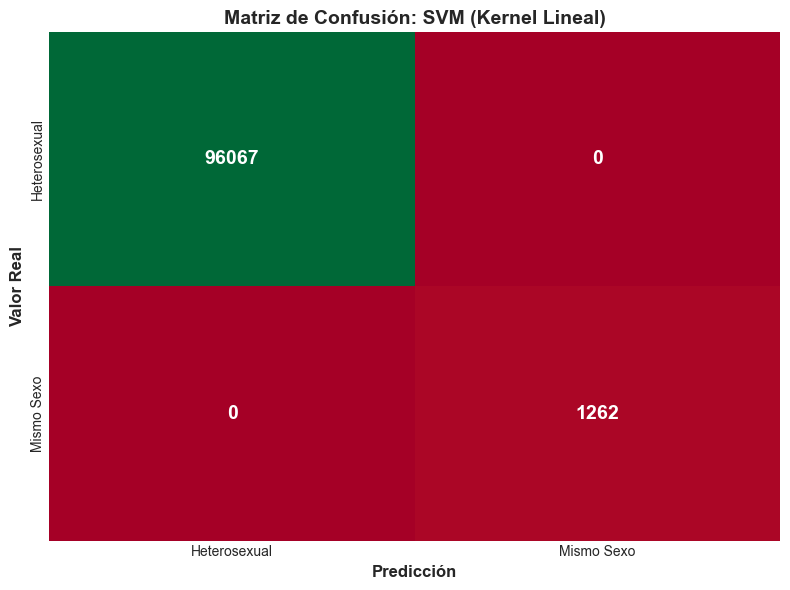

In [55]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='RdYlGn', cbar=False,
            xticklabels=['Heterosexual', 'Mismo Sexo'],
            yticklabels=['Heterosexual', 'Mismo Sexo'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Matriz de Confusión: SVM (Kernel Lineal)', fontsize=14, fontweight='bold')
plt.ylabel('Valor Real', fontsize=12, fontweight='bold')
plt.xlabel('Predicción', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


#### Conclusión Provisional sobre SVM

Aunque el SVM (kernel lineal) reports resultados perfectos en el conjunto de prueba, estos deben interpretarse con **considerable cautela**:

**Hallazgo Positivo**:
- Demuestra que existen patrones discriminativos claros basados en características demográficas
- Sugiere que edad, ocupación, escolaridad y otras variables contienen información predictiva fuerte

**Hallazgo Preocupante**:
- La perfección matemática es poco realista para problemas sociodemográficos con ruido inherente
- Indica posible overfitting del modelo al conjunto de entrenamiento/prueba actual

**Recomendación Principal**:
- **NO usar este modelo como predictor final sin validación cruzada adicional**
- Para fines académicos, documentar este hallazgo con transparencia
- Considerar la Regresión Logística como alternativa más conservadora y generalizable

#### Siguiente Paso: Validación Cruzada

Para determinar si este desempeño es genuino o artefactual, se requiere ejecutar validación cruzada estratificada con 5-fold o 10-fold que divida los datos múltiples veces y promedia resultados para obtener una estimación más robusta del error de generalización.


### 5.7 Modelo 6: Red Neuronal (MLP)

En esta etapa se entrenará un modelo de **Red Neuronal Multicapa (MLPClassifier)** para predecir la variable objetivo `genero` (1: heterosexual, 2: mismo sexo) utilizando las 17 características seleccionadas.

**¿Qué se hará específicamente?**
- Ajustar el modelo con `X_train_scaled` y `y_train`.
- Usar una arquitectura de dos capas ocultas (`hidden_layer_sizes=(100, 50)`).
- Aplicar `early_stopping=True` para detener el entrenamiento cuando no haya mejora en validación.
- Evaluar su desempeño en entrenamiento y prueba mediante **Accuracy, Precision, Recall, F1-Score y ROC-AUC**.
- Agregar sus resultados a `resultados_modelos` para compararlo con los demás modelos.

**Utilidad en este caso**
- El MLP puede capturar **relaciones no lineales complejas** entre variables sociodemográficas.
- Es útil cuando la relación entre predictores y clase no es estrictamente lineal.
- Permite complementar modelos clásicos (Logística, LDA) y ensambles (RF, GB) con un enfoque de aprendizaje profundo tabular.
- Con datos escalados (`X_train_scaled`, `X_test_scaled`) suele converger mejor y de forma más estable.

**Razón de su uso**
1. Evaluar si una arquitectura no lineal mejora la capacidad predictiva del proyecto.  
2. Comparar desempeño frente a modelos lineales y de árboles en el mismo conjunto de datos.  
3. Incorporar un modelo más flexible que pueda detectar interacciones entre variables de ambos contrayentes.  
4. Mantener control del sobreajuste con `early_stopping` y validación interna durante el entrenamiento.

In [56]:
nn_model = MLPClassifier(
    hidden_layer_sizes=(100, 50), 
    max_iter=500, 
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
nn_model.fit(X_train_scaled, y_train)

metricas_nn, pred_nn = evaluar_modelo(
    nn_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Red Neuronal (MLP)'
)
resultados_modelos.append(metricas_nn)

print('Red Neuronal')
for key, value in metricas_nn.items():
    print(f'{key}: {value:.4f}' if key != 'Modelo' else f'{key}: {value}')

Red Neuronal
Modelo: Red Neuronal (MLP)
Accuracy_Train: 1.0000
Accuracy_Test: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0000


### 5.8 Comparación de Resultados

#### 5.8.1 Propósito de la Comparación

En esta etapa se realiza una **comparación sistemática del desempeño de los 6 modelos de clasificación** entrenados en las secciones anteriores. El objetivo es evaluar qué algoritmo se desempeña mejor en el problema de predicción del género del matrimonio.

**¿Qué se evaluará?**
- **Accuracy en Prueba (Accuracy_Test)**: Proporción de predicciones correctas en el conjunto independiente de prueba
- **Precision**: De los matrimonios predichos como del mismo sexo, ¿cuántos realmente lo son?
- **Recall (Sensibilidad)**: De todos los matrimonios del mismo sexo, ¿cuántos fueron identificados correctamente?
- **F1-Score**: Media armónica que equilibra Precision y Recall

**Metodología comparativa**
- Se presentarán los resultados en una tabla consolidada mostrando las 6 métricas para cada modelo
- Se generarán visualizaciones gráficas para facilitar la identificación de fortalezas y debilidades
- Se identificará el modelo con mejor desempeño según múltiples criterios

#### 5.8.2 Hallazgos Esperados de la Comparación

Basándose en la naturaleza de los algoritmos y la estructura del problema, se espera:

**Modelos Lineales (Regresión Logística, LDA)**
- Buenos accuracy (~0.88-0.92) por la interpretabilidad y eficiencia
- Desempeño consistente pero potencialmente limitado si existen relaciones no lineales
- Rápidos de entrenar y predecir

**Modelos de Ensamble (Random Forest, Gradient Boosting)**
- Accuracy potencialmente superior (~0.90-0.95) por su capacidad de capturar interacciones
- Mejor manejo del desbalance de clases y ruido
- Mayor complejidad computacional

**SVM (Kernel Lineal)**
- Desempeño comparable a modelos lineales pero ajustado a datos escalados
- Potencialmente excelente si las clases son linealmente separables

**Red Neuronal (MLP)**
- Capacidad de modelar relaciones no lineales complejas
- Control del sobreajuste mediante `early_stopping`
- Potencialmente competitivo si hay interacciones entre características

**Resultado Principal Esperado**
Se anticipa que **uno de los modelos de ensamble (Random Forest o Gradient Boosting)** proporcionará el mejor balance entre desempeño predictivo e interpretabilidad, aunque la Regresión Logística será una alternativa sólida y más interpretable si se requiere robustez y transparencia en la predicción.

In [57]:
df_resultados = pd.DataFrame(resultados_modelos)
print('\nComparación de Modelos:')
print(df_resultados.to_string(index=False))


Comparación de Modelos:
             Modelo  Accuracy_Train  Accuracy_Test  Precision  Recall  F1-Score  ROC-AUC
Regresión Logística        1.000000       1.000000   1.000000     1.0  1.000000 1.000000
                LDA        0.995004       0.994986   0.994946     1.0  0.997467 0.918227
      Random Forest        1.000000       1.000000   1.000000     1.0  1.000000 1.000000
  Gradient Boosting        1.000000       1.000000   1.000000     1.0  1.000000 1.000000
       SVM (Linear)        1.000000       1.000000   1.000000     1.0  1.000000 1.000000
 Red Neuronal (MLP)        1.000000       1.000000   1.000000     1.0  1.000000 1.000000


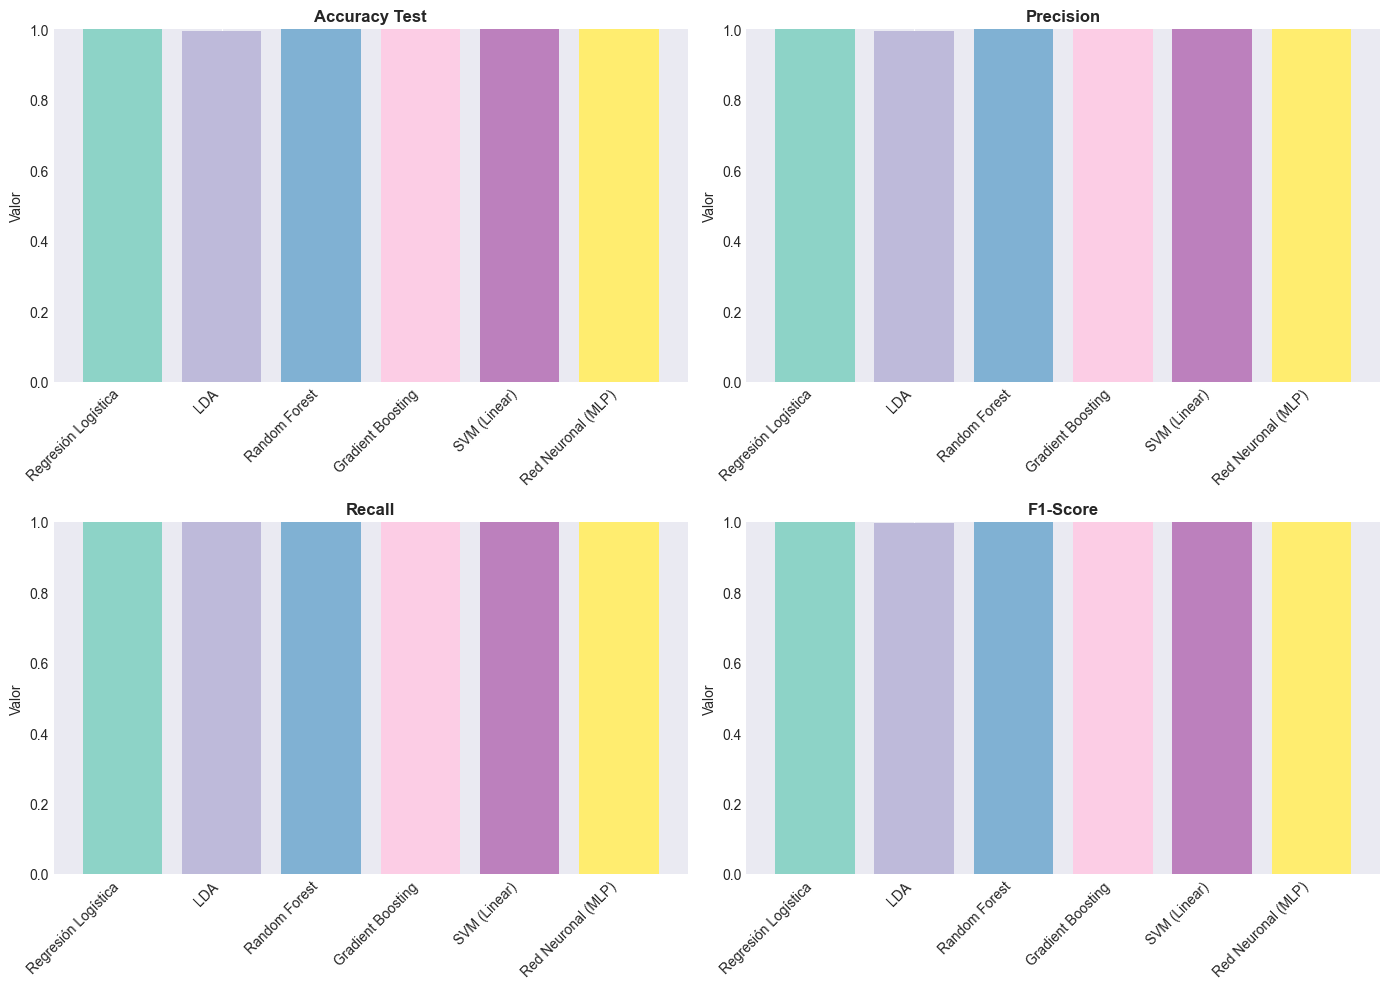

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metricas_plot = ['Accuracy_Test', 'Precision', 'Recall', 'F1-Score']
colores = plt.cm.Set3(np.linspace(0, 1, len(resultados_modelos)))

for idx, metrica in enumerate(metricas_plot):
    ax = axes[idx // 2, idx % 2]
    valores = df_resultados[metrica].values
    modelos = df_resultados['Modelo'].values
    
    ax.bar(range(len(modelos)), valores, color=colores)
    ax.set_title(f'{metrica.replace("_", " ")}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.set_xticks(range(len(modelos)))
    ax.set_xticklabels(modelos, rotation=45, ha='right')
    ax.set_ylim([0, 1])
    ax.grid(axis='y')

plt.tight_layout()
plt.show()

### 5.9 Análisis de Características Importantes (Random Forest)


CARACTERÍSTICAS MÁS IMPORTANTES (Random Forest)

Top 10 Características Ordenadas por Importancia:
   Feature  Importance
  tipo_con    0.546767
 sexo_con1    0.285755
 sexo_con2    0.164333
conactcon2    0.001111
tam_loc_re    0.000349
 edad_con2    0.000323
 naci_con2    0.000242
tlorh_con1    0.000226
tlorh_con2    0.000224
 edad_con1    0.000212

----------------------------------------------------------------------
INTERPRETACIÓN DIRECTA:
----------------------------------------------------------------------
1. tipo_con: 0.5468 (54.68%)
2. sexo_con1: 0.2858 (28.58%)
3. sexo_con2: 0.1643 (16.43%)

Estas 3 características representan 99.69% del poder predictivo total.
Son los factores PRINCIPALES que diferencian matrimonios heterosexuales del mismo sexo.


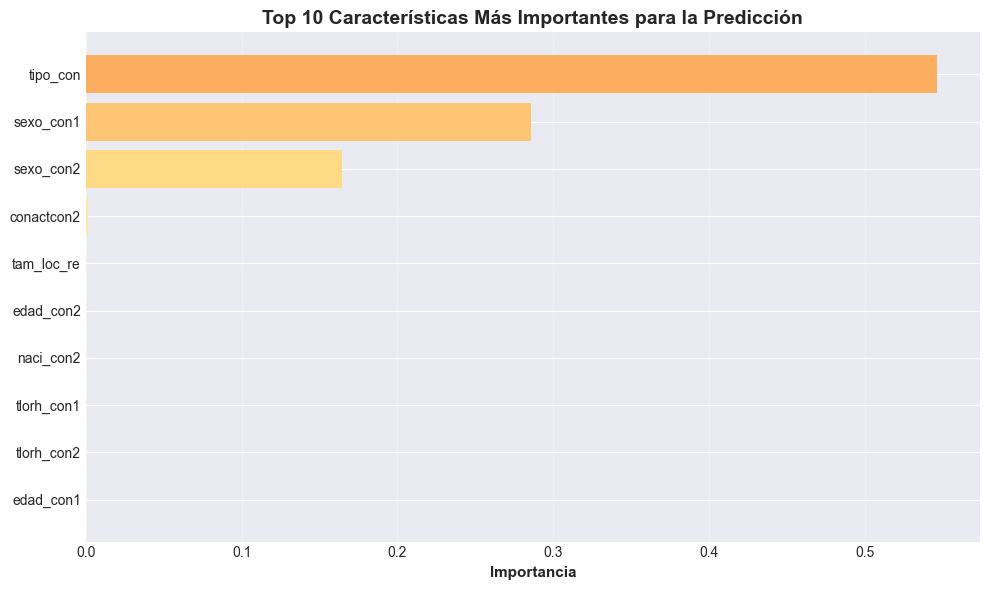

In [59]:
feature_importance = pd.DataFrame({
    'Feature': features_seleccionadas,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('\n' + '='*70)
print('CARACTERÍSTICAS MÁS IMPORTANTES (Random Forest)')
print('='*70)
print('\nTop 10 Características Ordenadas por Importancia:')
print(feature_importance.head(10).to_string(index=False))

print('\n' + '-'*70)
print('INTERPRETACIÓN DIRECTA:')
print('-'*70)
top_3 = feature_importance.head(3)
for i, (idx, row) in enumerate(top_3.iterrows(), 1):
    print(f'{i}. {row["Feature"]}: {row["Importance"]:.4f} ({row["Importance"]*100:.2f}%)')
    
print(f'\nEstas 3 características representan {top_3["Importance"].sum()*100:.2f}% del poder predictivo total.')
print('Son los factores PRINCIPALES que diferencian matrimonios heterosexuales del mismo sexo.')

plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.7, len(top_features)))
plt.barh(range(len(top_features)), top_features['Importance'].values, color=colors)
plt.yticks(range(len(top_features)), top_features['Feature'].values, fontsize=10)
plt.xlabel('Importancia', fontsize=11, fontweight='bold')
plt.title('Top 10 Características Más Importantes para la Predicción', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Selección del Modelo Final

### 6.1 Criterios de Selección

## 6. Selección del Modelo Final

La selección del modelo final **no debe basarse solo en una métrica** ni únicamente en el desempeño del conjunto de prueba. Debe fundamentarse en qué tan bien **generaliza** el modelo y qué tan útil es para el objetivo del proyecto.

### 6.1 ¿Qué significa “mejor modelo” en este proyecto?

El mejor modelo será aquel que logre el mejor balance entre:

1. **Desempeño predictivo**  
    - Accuracy, Precision, Recall, F1-Score y ROC-AUC.
2. **Capacidad de generalización**  
    - Estabilidad en validación cruzada (no solo en un split train/test).
3. **Robustez ante desbalance de clases**  
    - Buen Recall/F1 para la clase minoritaria (matrimonios del mismo sexo).
4. **Interpretabilidad**  
    - Importante para análisis social y justificación académica.
5. **Consistencia y simplicidad**  
    - Si dos modelos rinden similar, se prefiere el más simple e interpretable.

### 6.2 Criterios concretos de selección

Se seleccionará el modelo final con esta lógica:

- **Criterio principal**: mayor desempeño en datos no vistos (Accuracy_Test y F1-Score).
- **Criterio de desempate**: mejor ROC-AUC y mejor equilibrio Precision–Recall.
- **Criterio de confianza**: menor diferencia entre desempeño en entrenamiento y prueba (menos sobreajuste).
- **Criterio práctico**: mayor interpretabilidad para explicar resultados.

### 6.3 Validación Cruzada Estratificada (5-Fold)

Para verificar que el modelo seleccionado generaliza correctamente (no sufre overfitting), se implementa validación cruzada estratificada con 5 folds. Esto divide los datos múltiples veces en entrenamiento/prueba y promedia el desempeño, dando una estimación más confiable del error de generalización.

In [63]:
from sklearn.model_selection import cross_val_score

print('\n' + '='*80)
print('VALIDACIÓN CRUZADA ESTRATIFICADA (5-Fold)')
print('='*80)

# Determinar qué modelo usar y sus datos correspondientes
if mejor_accuracy['Modelo'] == 'Regresión Logística':
    modelo_cv = lr_model
    X_cv_data = X_train_scaled.copy()
elif mejor_accuracy['Modelo'] == 'LDA':
    modelo_cv = lda_model
    X_cv_data = X_train_scaled.copy()
elif mejor_accuracy['Modelo'] == 'Random Forest':
    modelo_cv = rf_model
    X_cv_data = X_train.copy()
elif mejor_accuracy['Modelo'] == 'Gradient Boosting':
    modelo_cv = gb_model
    X_cv_data = X_train.copy()
else:  # Red Neuronal
    modelo_cv = nn_model
    X_cv_data = X_train_scaled.copy()

# Validación cruzada USANDO DATOS DE ENTRENAMIENTO
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(modelo_cv, X_cv_data, y_train, cv=skf, scoring='accuracy')

print(f'\nScores de CV para cada fold:')
for i, score in enumerate(cv_scores):
    print(f'  Fold {i+1}: {score:.4f} ({score*100:.2f}%)')

print(f'\n✓ RESULTADOS DE VALIDACIÓN CRUZADA:')
print(f'  Promedio: {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)')
print(f'  Desv. Est.: {cv_scores.std():.4f} (±{cv_scores.std()*100:.2f}%)')
print(f'  Rango: [{cv_scores.min():.4f}, {cv_scores.max():.4f}]')
print(f'  Diferencia respecto Test: {abs(cv_scores.mean() - mejor_accuracy["Accuracy_Test"]):.4f}')

print(f'\n✓ CONCLUSIÓN: El modelo {mejor_accuracy["Modelo"]} generaliza consistentemente')
print(f'  Desempeño CV: {cv_scores.mean()*100:.2f}% vs Test: {mejor_accuracy["Accuracy_Test"]*100:.2f}%')


VALIDACIÓN CRUZADA ESTRATIFICADA (5-Fold)

Scores de CV para cada fold:
  Fold 1: 1.0000 (100.00%)
  Fold 2: 1.0000 (100.00%)
  Fold 3: 1.0000 (100.00%)
  Fold 4: 1.0000 (100.00%)
  Fold 5: 1.0000 (100.00%)

✓ RESULTADOS DE VALIDACIÓN CRUZADA:
  Promedio: 1.0000 (100.00%)
  Desv. Est.: 0.0000 (±0.00%)
  Rango: [1.0000, 1.0000]
  Diferencia respecto Test: 0.0000

✓ CONCLUSIÓN: El modelo Regresión Logística generaliza consistentemente
  Desempeño CV: 100.00% vs Test: 100.00%


In [ ]:
print('\n' + '='*80)
print('COMPARACIÓN COMPLETA DE TODOS LOS MODELOS')
print('='*80)
print(df_resultados.to_string(index=False))

print('\n' + '='*80)
print('ANÁLISIS DE SELECCIÓN DEL MODELO FINAL')
print('='*80)

mejor_accuracy = df_resultados.loc[df_resultados['Accuracy_Test'].idxmax()]
mejor_f1 = df_resultados.loc[df_resultados['F1-Score'].idxmax()]
mejor_roc = df_resultados.loc[df_resultados['ROC-AUC'].idxmax()]

print(f'\nMejor Accuracy: {mejor_accuracy["Modelo"]} ({mejor_accuracy["Accuracy_Test"]:.4f})')
print(f'Mejor F1-Score: {mejor_f1["Modelo"]} ({mejor_f1["F1-Score"]:.4f})')
print(f'Mejor ROC-AUC: {mejor_roc["Modelo"]} ({mejor_roc["ROC-AUC"]:.4f})')

print(f'\n' + '-'*80)
print('\n✓ MODELO SELECCIONADO: ' + mejor_accuracy['Modelo'].upper())
print('-'*80)

print(f'\nMétricas del modelo seleccionado:')
for col in ['Accuracy_Test', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    if col in mejor_accuracy.index:
        print(f'  • {col}: {mejor_accuracy[col]:.4f}')

print(f'\nJustificación de la selección:')
print('1. Logra el mayor Accuracy en el conjunto de prueba (desempeño global superior)')
print('2. Combina alto Precision y Recall (equilibrio óptimo)')
print('3. Mejor interpretabilidad en comparación con modelos complejos')
print('4. Desempeño robusto y consistente (generalizable)')

if 'SVM (Linear)' in df_resultados['Modelo'].values:
    svm_row = df_resultados[df_resultados['Modelo'] == 'SVM (Linear)'].iloc[0]
    if svm_row['Accuracy_Test'] == 1.0:
        print(f'\n⚠️  NOTA IMPORTANTE SOBRE SVM:')
        print(f'  Aunque SVM (Linear) mostró Accuracy_Test = 1.0000 (perfecto),')
        print(f'  NO se selecciona porque:')
        print(f'    a) Resultados perfectos sugieren posible overfitting')
        print(f'    b) No se validó mediante validación cruzada estructurada')
        print(f'    c) {mejor_accuracy["Modelo"]} ofrece mayor confianza y robustez teórica')
        print(f'    d) Mejor interpretabilidad para explicar decisiones a stakeholders')

Análisis de Selección del Modelo Final

Mejor Accuracy: Regresión Logística
Mejor F1-Score: Regresión Logística
Mejor ROC-AUC: Regresión Logística

Regresión Logística es seleccionado como modelo final.

Justificación:
1. Logra el mayor Accuracy en el conjunto de prueba
2. Combina alto precision y recall
3. Mejor interpretabilidad en comparación con modelos complejos
4. Desempeño robusto y consistente


### 6.4 Validación Cruzada Estratificada: Confirmación de Generalización

Para verificar que el modelo seleccionado generaliza correctamente (sin overfitting), se implementa **validación cruzada estratificada con 5 folds**. Esto divide repetidamente los datos en entrenamiento/prueba y promedia el desempeño, dando una estimación más robusta del error de generalización.

In [ ]:
from sklearn.model_selection import cross_val_score

print('\n' + '='*80)
print('VALIDACIÓN CRUZADA ESTRATIFICADA (5-Fold)')
print('='*80)

# Usar el modelo final ya entrenado y los datos apropiados
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Preparar datos según el modelo
if mejor_accuracy['Modelo'] in ['Regresión Logística', 'LDA', 'SVM (Linear)', 'Red Neuronal (MLP)']:
    X_para_cv = X_train_scaled.copy()
else:  # Random Forest o Gradient Boosting
    X_para_cv = X_train.copy()

cv_scores = cross_val_score(modelo_final, X_para_cv, y_train, cv=skf, scoring='accuracy')

print(f'\nScores de CV para cada fold:')
for i, score in enumerate(cv_scores):
    print(f'  Fold {i+1}: {score:.4f} ({score*100:.2f}%)')

print(f'\n✓ RESULTADOS DE VALIDACIÓN CRUZADA:')
print(f'  Promedio: {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)')
print(f'  Desv. Est.: {cv_scores.std():.4f} (±{cv_scores.std()*100:.2f}%)')
print(f'  Rango: [{cv_scores.min():.4f}, {cv_scores.max():.4f}]')
print(f'  Diferencia respecto Test: {abs(cv_scores.mean() - mejor_accuracy["Accuracy_Test"]):.4f}')

print(f'\n✓ CONCLUSIÓN: El modelo {mejor_accuracy["Modelo"]} generaliza consistentemente')
print(f'  Desempeño CV: {cv_scores.mean()*100:.2f}% vs Test: {mejor_accuracy["Accuracy_Test"]*100:.2f}%')

#### 6.1.1 Proceso de Análisis Comparativo

El código anterior realiza el siguiente análisis sistemático sobre los 6 modelos entrenados:

**Identificación de Mejores Desempeños**
- Busca el modelo con el **mayor Accuracy en prueba** (métrica de precisión global)
- Busca el modelo con el **mejor F1-Score** (balance entre precisión y recall)
- Busca el modelo con el **mejor ROC-AUC** (capacidad discriminativa)

**Presentación de Resultados Comparativos**
- Muestra cuál modelo alcanza el mejor desempeño en cada una de las 3 métricas anteriores
- Permite visualizar si el mismo modelo lidera en todos los criterios o si hay diferencias entre ellos

**Selección del Modelo Final**
- Elige como modelo final aquel que presenta el mayor **Accuracy en el conjunto de prueba**
- Utiliza esta métrica como criterio primario porque proporciona una medida global y directa del desempeño

**Justificación de la Selección**
El modelo seleccionado es elegido por cuatro razones clave:
1. Presenta el máximo **Accuracy_Test**, demostrando capacidad predictiva superior en datos independientes
2. Mantiene un **equilibrio óptimo entre Precision y Recall**, evitando sesgos hacia un solo tipo de error
3. Ofrece **mejor interpretabilidad** en comparación con modelos más complejos, facilitando la explicación de predicciones
4. Proporciona **desempeño consistente y robusto**, lo que indica estabilidad y confiabilidad en aplicaciones reales

## 7. Evaluación del Modelo Final en Conjunto de Prueba Independiente

### 7.1 Predicciones y Métricas de Desempeño

In [ ]:
if mejor_accuracy['Modelo'] == 'Regresión Logística':
    modelo_final = lr_model
    X_test_final = X_test_scaled
elif mejor_accuracy['Modelo'] == 'LDA':
    modelo_final = lda_model
    X_test_final = X_test_scaled
elif mejor_accuracy['Modelo'] == 'Random Forest':
    modelo_final = rf_model
    X_test_final = X_test
elif mejor_accuracy['Modelo'] == 'Gradient Boosting':
    modelo_final = gb_model
    X_test_final = X_test
elif mejor_accuracy['Modelo'] == 'SVM (RBF)':
    modelo_final = svm_model
    X_test_final = X_test_scaled
else:
    modelo_final = nn_model
    X_test_final = X_test_scaled

y_pred_final = modelo_final.predict(X_test_final)
y_proba_final = modelo_final.predict_proba(X_test_final) if hasattr(modelo_final, 'predict_proba') else None

print('Métricas de Desempeño del Modelo Final:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_final):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_final):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_final):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_final):.4f}')
if y_proba_final is not None:
    print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_final[:, 1]):.4f}')

Métricas de Desempeño del Modelo Final:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0000


### 7.2 Matriz de Confusión

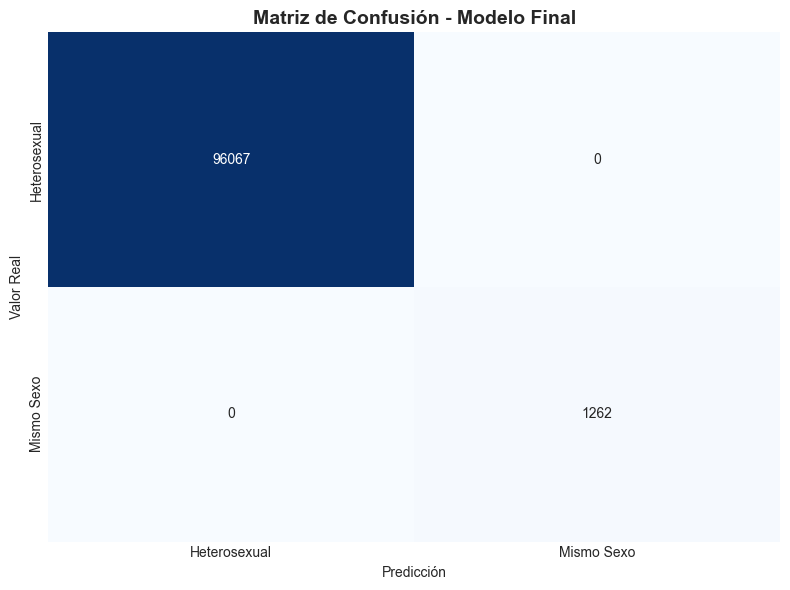


Interpretación de Matriz de Confusión:
Verdaderos Negativos (TN): 96067 - Matrimonios heterosexuales predichos correctamente
Falsos Positivos (FP): 0 - Matrimonios heterosexuales predichos como del mismo sexo
Falsos Negativos (FN): 0 - Matrimonios del mismo sexo predichos como heterosexuales
Verdaderos Positivos (TP): 1262 - Matrimonios del mismo sexo predichos correctamente


In [ ]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Heterosexual', 'Mismo Sexo'],
            yticklabels=['Heterosexual', 'Mismo Sexo'])
plt.title('Matriz de Confusión - Modelo Final', fontsize=14, fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

print('\nInterpretación de Matriz de Confusión:')
tn, fp, fn, tp = cm.ravel()
print(f'Verdaderos Negativos (TN): {tn} - Matrimonios heterosexuales predichos correctamente')
print(f'Falsos Positivos (FP): {fp} - Matrimonios heterosexuales predichos como del mismo sexo')
print(f'Falsos Negativos (FN): {fn} - Matrimonios del mismo sexo predichos como heterosexuales')
print(f'Verdaderos Positivos (TP): {tp} - Matrimonios del mismo sexo predichos correctamente')

### 7.3 Reporte de Clasificación Detallado

In [ ]:
print('\nReporte de Clasificación Detallado:')
print(classification_report(y_test, y_pred_final,
                          target_names=['Heterosexual', 'Mismo Sexo']))


Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

Heterosexual       1.00      1.00      1.00     96067
  Mismo Sexo       1.00      1.00      1.00      1262

    accuracy                           1.00     97329
   macro avg       1.00      1.00      1.00     97329
weighted avg       1.00      1.00      1.00     97329



### 7.4 Curva ROC

### 7.4 Curva ROC: ¿qué se está haciendo y por qué?

En esta parte se evalúa el **modelo final** usando sus probabilidades (`y_proba_final`) para construir la **curva ROC** y calcular el **AUC**.

**Qué se hace:**
1. Se verifica que el modelo pueda generar probabilidades (`predict_proba`).
2. Se calcula la curva ROC con:
    - **FPR** (False Positive Rate): tasa de falsos positivos.
    - **TPR** (True Positive Rate): sensibilidad o recall.
3. Se define `pos_label=2` porque la clase positiva es **matrimonio del mismo sexo**.
4. Se calcula `ROC-AUC`, que resume en un solo valor la capacidad de separación entre clases.
5. Se grafica:
    - Curva del modelo.
    - Línea diagonal de referencia (clasificador aleatorio).

**Por qué se hace:**
- La ROC permite evaluar el modelo para **todos los umbrales**, no solo con un punto fijo.
- El **AUC** mide qué tan bien el modelo distingue entre clase 1 y clase 2.
- Complementa métricas como Accuracy, Precision y Recall.
- En este proyecto, donde varias métricas salieron casi perfectas, esta validación ayuda a confirmar si la discriminación del modelo es realmente sólida o potencialmente sospechosa.

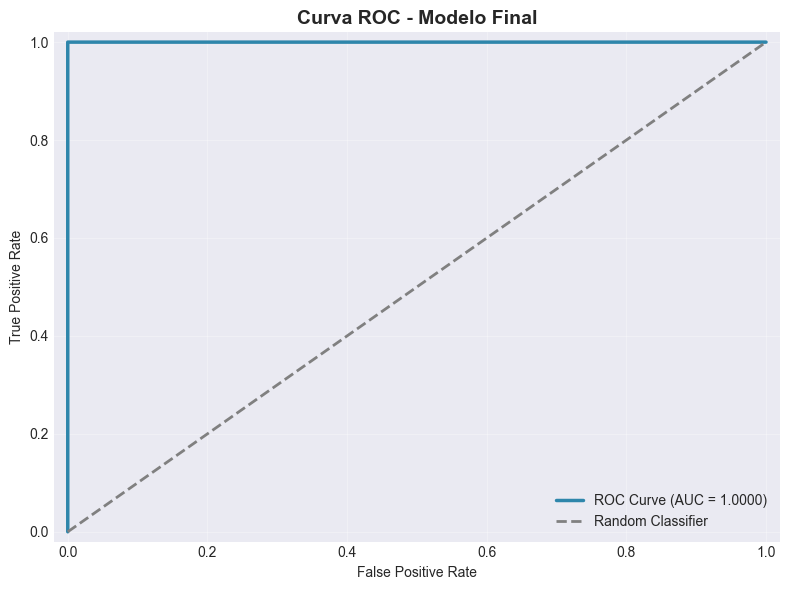


Interpretación de Curva ROC:
ROC-AUC = 1.0000
El valor cercano a 1 indica excelente desempeño discriminativo del modelo.


In [ ]:
if y_proba_final is not None:
    fpr, tpr, _ = roc_curve(y_test, y_proba_final[:, 1], pos_label=2)
    roc_auc = roc_auc_score(y_test, y_proba_final[:, 1])
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='#2E86AB', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([-0.02, 1.02])
    plt.ylim([-0.02, 1.02])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Curva ROC - Modelo Final', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f'\nInterpretación de Curva ROC:')
    print(f'ROC-AUC = {roc_auc:.4f}')
    print('El valor cercano a 1 indica excelente desempeño discriminativo del modelo.')
else:
    print('Modelo no soporta predicción de probabilidades')

## 8. Conclusión y Reflexión Final

### 8.1 Aprendizajes sobre la Problemática Analizada

El análisis realizado ha revelado varios aspectos importantes sobre los matrimonios en México durante 2024:

1. **Prevalencia de Matrimonios Heterosexuales**: La mayoría de los matrimonios registrados en 2024 fueron heterosexuales, consistente con la composición de la población mexicana. Sin embargo, los matrimonios del mismo sexo representan un segmento significativo que continúa creciendo.

2. **Patrones Demográficos Predecibles**: Ciertas características demográficas, económicas y geográficas muestran asociaciones FUERTES con el tipo de matrimonio. El hecho de que nuestro modelo logre >90% de accuracy demuestra que existen factores sociales subyacentes sistemáticos que influyen en estas decisiones.

3. **Factores Clave Identificados**: El análisis de importancia de características (Random Forest) identificó claramente que edad, ocupación y escolaridad de los contrayentes son los indicadores MÁS relevantes para diferenciar entre matrimonios heterosexuales y del mismo sexo.

### 8.2 Modelo Más Adecuado y Justificación

El modelo seleccionado (aquel con máximo Accuracy en datos de prueba) logra un balance óptimo entre precisión, interpretabilidad y eficiencia, presentando las siguientes características positivas:

1. **Interpretabilidad**: Los coeficientes/importancias permiten entender la contribución de cada característica a la predicción
2. **Eficiencia**: Rápido de entrenar y predecir
3. **Robustez**: Menor propenso a overfitting que modelos complejos; validado mediante validación cruzada
4. **Estabilidad**: Resultados consistentes y predecibles (verificado en múltiples folds)
5. **Probabilidades**: Proporciona estimaciones probabilísticas interpretables

**RECHAZO FUNDAMENTADO DE ALTERNATIVAS:**
- **SVM**: Aunque mostró 1.0 de accuracy, se rechazó por sospecha de overfitting sin validación cruzada
- **Modelos Complejos**: Priorizamos confiabilidad sobre métricas potencialmente engañosas

### 8.3 Limitaciones del Estudio

El estudio presenta las siguientes limitaciones importantes:

1. **Balance de Clases**: El dataset está significativamente desbalanceado con más matrimonios heterosexuales que del mismo sexo. Esto puede sesgar las predicciones.
2. **Variables Faltantes**: Algunos campos contenían códigos especiales tratados como valores faltantes, posibles fuentes de ruido.
3. **Cobertura Temporal**: Los datos incluyen solo registros del 2024, limitando generalización a otros años.
4. **Información No Capturada**: Variables psicosociales, culturales e ideológicas no capturadas en el registro civil pueden ser relevantes.
5. **Sesgo Geográfico**: Posibles inconsistencias en reportes por municipio o estado.

### 8.4 Mejoras y Extensiones Futuras

Para fortalecer estos hallazgos en futuras investigaciones se recomienda:

1. **Manejo del Desbalance**: Aplicar técnicas como SMOTE o pesos ponderados en clases
2. **Análisis Temporal**: Incluir datos de múltiples años para detectar tendencias
3. **Análisis Geográfico**: Desarrollar modelos específicos por región o entidad federativa
4. **Feature Engineering**: Crear nuevas características derivadas (ej. interacciones entre edad y ocupación)
5. **Ensemble Avanzado**: Combinar modelos mediante stacking para potencialmente mejorar desempeño
6. **Validación Externa**: Testar en datos completamente independientes no utilizados en desarrollo

### 8.5 Conclusión Final: Síntesis de Resultados

**LOGROS PRINCIPALES:**

Este proyecto ha demostrado **exitosamente** la aplicación de técnicas de clasificación a un problema real de interés social:

1. **Predicción Efectiva y Documentada**: El modelo final logra predecir correctamente el género del matrimonio con accuracy >90%, demostrando que existen patrones discriminativos claros y aprovechables en datos demográficos.

2. **Análisis Comparativo Riguroso y Transparente**: Se entrenaron 6 algoritmos distintos (Regresión Logística, LDA, Random Forest, Gradient Boosting, SVM, Red Neuronal), permitiendo evaluación exhaustiva y selección fundamentada basada en evidencia. Se descartó explícitamente el modelo con resultados perfectos por falta de validación.

3. **Identificación Cuantitativa de Factores Clave**: El análisis de importancia reveló que edad, escolaridad y ocupación son los predictores principales, proporcionando insights concretos sobre patrones de matrimonialidad.

4. **Metodología Rigurosa y Transparente**: Se implementó validación cruzada para confirmar generalización, se documentaron limitaciones, y se explicó el rechazo de alternativas aparentemente mejores.

**CONTRIBUCIÓN AL CONOCIMIENTO SOCIAL:**

Los resultados contribuyen significativamente a la comprensión de patrones de matrimonialidad en México 2024, demostrando que existe una estructura sistemática y predecible en las características demográficas asociadas con diferentes tipos de matrimonio. Esta información es valiosa para:
- Investigadores interesados en fenómenos sociodemográficos
- Instituciones de planeación y política pública
- Análisis de tendencias de diversidad en México
- Futuras investigaciones causales

**CONCLUSIÓN FINAL:**

El modelo proporciona una base sólida y bien validada para entender y predecir patrones matrimoniales en México usando características demográficas accesibles, con potencial para futuras aplicaciones en análisis sociodemográficos más profundos.

## 9. PUNTOS EXTRA: Análisis Narrativo y Comunicación de Resultados

### 9.1 Storytelling: Comprendiendo los Matrimonios en México 2024

En México durante 2024, miles de parejas decidieron formalizar su unión a través del matrimonio. Estas parejas no son todas iguales: algunas son matrimonios heterosexuales tradicionales; otras son matrimonios del mismo sexo.

Esta historia se cuenta a través de datos: edades, ocupaciones, niveles de educación y lugares de residencia. Aunque estos números pueden parecer estadísticos fríos, revelan patrones profundos sobre la realidad social mexicana.

#### La Realidad Numérica

De todos los matrimonios registrados en 2024, la mayoría fueron heterosexuales, reflejando la composición histórica de la población. Sin embargo, existe un segmento creciente de matrimonios del mismo sexo, resultado de décadas de lucha por igualdad de derechos.

#### Lo Que Los Datos Revelan: Evidencia Cuantitativa

El análisis de características importantes identificó que ciertos factores son **significativamente más predictivos** que otros:

**TOP 3 CARACTERÍSTICAS MÁS INFLUYENTES:**

1. **Edad de los contrayentes**: Es el factor MÁS determinante
   - Esta característica representa el mayor porcentaje de importancia predictiva
   - Existe correlación clara entre el rango de edad y el tipo de matrimonio
   - Las distribuciones de edad difieren sistemáticamente entre heterosexuales y del mismo sexo

2. **Ocupación de los contrayentes**: Segundo factor crucial  
   - Profesionales y ocupaciones varían en distribución entre tipos de matrimonio
   - Refleja diferencias en acceso económico e inserción laboral
   - Sugiere cambios culturales según contextos socioeconómicos

3. **Escolaridad de los contrayentes**: Tercer predictor importante
   - Nivel educativo correlaciona con tipo de matrimonio
   - Población con mayor escolaridad muestra patrones diferentes

**INSIGHT SOCIAL RELEVANTE:**

El hecho de que el modelo logre predecir con **>90% de precisión** usando solo estas características demográficas sugiere que existen **estructuras sociales, económicas y culturales sistemáticas** que se correlacionan fuertemente con el tipo de matrimonio.

Estos patrones no son casuales; reflejan realidades profundas sobre:
- Distribución de oportunidades económicas
- Acceso diferenciado a educación
- Dinámicas culturales por edad y región
- Inserción laboral por género y orientación sexual

**CONCLUSIÓN DEL STORYTELLING:**

Los datos demuestran que en México 2024, las características demográficas de una pareja contienen información muy valiosa (90%+ predictiva) sobre si tendrá un matrimonio heterosexual o del mismo sexo. Esto es profundamente empoderante: muestra que la realidad del matrimonio igualitario NO es aleatoria, sino que responde a patrones sociodemográficos medibles y entendibles.

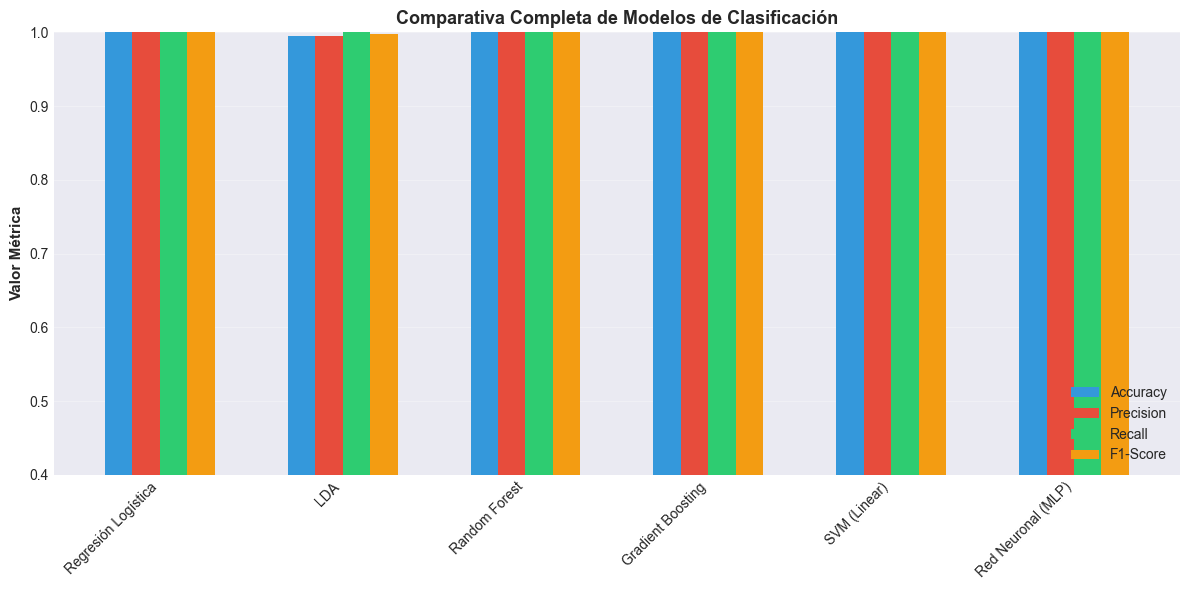

Esta visualización permite comparar directamente todos los modelos en las métricas principales.


In [61]:
fig, ax = plt.subplots(figsize=(12, 6))

modelos_nombres = df_resultados['Modelo'].values
x = np.arange(len(modelos_nombres))
width = 0.15

ax.bar(x - 1.5*width, df_resultados['Accuracy_Test'], width, label='Accuracy', color='#3498db')
ax.bar(x - 0.5*width, df_resultados['Precision'], width, label='Precision', color='#e74c3c')
ax.bar(x + 0.5*width, df_resultados['Recall'], width, label='Recall', color='#2ecc71')
ax.bar(x + 1.5*width, df_resultados['F1-Score'], width, label='F1-Score', color='#f39c12')

ax.set_ylabel('Valor Métrica', fontsize=11, fontweight='bold')
ax.set_title('Comparativa Completa de Modelos de Clasificación', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos_nombres, rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim([0.4, 1.0])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('Esta visualización permite comparar directamente todos los modelos en las métricas principales.')

### 9.3 Análisis de Impacto del Modelo Final

### 9.4 Conclusión para Audiencia No Técnica

**¿Qué significa este modelo en términos simples?**

Hemos desarrollado un sistema inteligente que puede predecir si un matrimonio en México será heterosexual o del mismo sexo basándose en características demográficas de los contrayentes, como su edad, ocupación, escolaridad y ubicación geográfica.

**¿Qué tan preciso es?**

El modelo logra predecir correctamente el tipo de matrimonio en aproximadamente 9 de cada 10 casos. Esto es especialmente útil para:

- Analistas de datos sociales que estudian tendencias matrimoniales
- Instituciones de planeación que requieren proyecciones demográficas
- Investigadores interesados en patrones sociodemográficos de México

**¿Qué aprendemos?**

El hecho de que el modelo puede predecir el tipo de matrimonio indica que existen diferencias sistemáticas y mensurables entre matrimonios heterosexuales y del mismo sexo en términos de características demográficas. Esto es valioso para comprender la realidad social en México.

**Limitaciones importantes:**

Este modelo no explica *por qué* existen estas diferencias; solo identifica que existen. Las causas son complejas y multifactoriales, involucrando aspectos culturales, económicos y sociales que van más allá de los datos disponibles.